# Optimización de Carteras de Markowitz y Modelización de Value at Risk (VaR)

En este cuaderno realizo la optimización de una cartera diversificada con 5 activos: renta variable estadounidense, renta variable europea, renta variable china, mercados emergentes (ex-China) y oro como activo refugio.

El proyecto se divide en tres fases:
1. Optimización de Markowitz: Calculo la frontera eficiente y selecciono tres carteras:
   * Cartera equitativa ($1/N$): Reparto del 20% en cada activo (cartera base o subóptima).
   * Cartera de mínima varianza: La combinación de activos que consigue la menor volatilidad posible.
   * Cartera de máximo Sharpe: La cartera que maximiza la rentabilidad por cada unidad de riesgo asumida.
2. Modelización de Riesgo: Para estas tres carteras, calculo el Value at Risk (VaR) y el Expected Shortfall (CVaR) al 99% de confianza utilizando tres métodos: paramétrico, simulación histórica y simulación de Monte Carlo.
3. Calibración y Backtesting: Utilizo los datos de 2019 a 2024 para calibrar y entrenar los modelos, y los datos de 2025 y 2026 para hacer backtesting y evaluar cómo se comportan fuera de la muestra.

### Importación de librerías

In [1]:
import numpy as np
import pandas as pd
import datetime as dt
import yfinance as yf
from pypfopt.efficient_frontier import EfficientFrontier
from pypfopt import plotting
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.stats import chi2

Estas son librerias necesarias para ejecutar el notebook.

### Periodos de calibración y backtesting

Dividimos los datos en dos ventanas temporales:

* Ventana de calibración (In-Sample, 2019 - 2024): Con estos datos calculamos las rentabilidades esperadas, la matriz de covarianzas, los pesos óptimos y los modelos de VaR. Elegimos este periodo porque recoge momentos de alta volatilidad (como la crisis del COVID-19 en 2020 y la guerra de Ucrania en 2022) junto a periodos de mayor estabilidad.
* Ventana de prueba (Out-of-Sample / Backtesting, 2025 - 2026): Usamos los datos más recientes para comprobar si las estimaciones de riesgo se cumplen en la realidad sin sesgar los cálculos iniciales.

In [2]:
# Ventana In-Sample (Calibración de Markowitz y VaR)
start_date_in_sample = '2019-01-01'
end_date_in_sample = '2024-12-31'

#Ventana Out-of-Sample (Backtesting de Excepciones)
start_date_out_sample = '2025-01-01'
end_date_out_sample = '2026-08-25'

### Descarga y preparación de los datos históricos

Definimos los 5 activos seleccionados y descargamos sus precios de cierre ajustados (*Adjusted Close*) para la ventana de calibración (*in-sample*). 

Utilizamos el precio ajustado porque descuenta automáticamente el impacto de dividendos y *splits*, lo que nos da la rentabilidad económica real de cada activo.

In [3]:
# Universo de 5 activos líquidos
tickers = ["SPY", "VGK", "GLD", "ASHR", "EMXC"]

# Descarga activos
data = yf.download(tickers, start=start_date_in_sample, end=end_date_in_sample, auto_adjust=False)

# Nos quedamos con el precio de cierre ajustado y eliminamos posibles filas vacías
adj_close_df = data['Adj Close'][tickers].dropna()

adj_close_df

[                       0%                       ]

[*******************   40%                       ]  2 of 5 completed

[**********************60%****                   ]  3 of 5 completed

[**********************80%*************          ]  4 of 5 completed

[*********************100%***********************]  5 of 5 completed

Ticker,SPY,VGK,GLD,ASHR,EMXC
Date,,,,,
2019-01-02,223.805969,37.735981,121.330002,19.741053,38.502136
2019-01-03,218.465332,37.455017,122.430000,19.514248,38.129410
2019-01-04,225.783005,38.578888,121.440002,20.412392,39.094799
2019-01-07,227.563217,38.750595,121.860001,20.330744,39.177902
2019-01-08,229.701248,39.062794,121.529999,20.357958,39.153564
...,...,...,...,...,...
2024-12-23,584.680298,60.536907,240.960007,26.027531,54.285355
2024-12-24,591.179138,60.870205,241.440002,26.437874,54.266071
2024-12-26,591.218445,61.032089,243.070007,26.486727,53.967163


### Cálculo de Rendimientos Logarítmicos

Transformamos la serie de precios diarios en rendimientos logarítmicos continuos utilizando la fórmula:

$$r_t = \ln\left(\frac{P_t}{P_{t-1}}\right)$$

Utilizamos rendimientos logarítmicos por tres razones principales:
1. Aditividad temporal: Permiten sumar rendimientos a lo largo del tiempo de forma directa y facilitan su anualización multiplicando por 252 días de negociación.
2. Propiedades estadísticas: Convierten las series de precios (no estacionarias) en series estacionarias con media y varianza más estables.
3. Modelización de riesgo: Son el estándar en la modelización cuantitativa y simulaciones estocásticas de VaR (supuesto de paseo aleatorio / Movimiento Browniano Geométrico).

In [4]:
log_returns = np.log(adj_close_df/adj_close_df.shift(1))  
log_returns = log_returns.dropna() 
log_returns.head()

Ticker,SPY,VGK,GLD,ASHR,EMXC
Date,,,,,
2019-01-03,-0.024152,-0.007473,0.009025,-0.011555,-0.009728
2019-01-04,0.032947,0.029565,-0.008119,0.044997,0.025004
2019-01-07,0.007854,0.004441,0.003453,-0.004008,0.002123
2019-01-08,0.009351,0.008024,-0.002712,0.001338,-0.000621
2019-01-09,0.004663,0.012509,0.006398,0.018981,0.015298


## 1. Optimización de Carteras Modelo de Markowitz

### Parámetros del modelo

Para alimentar el algoritmo de optimización media-varianza necesitamos estimar dos entradas estadísticas clave a partir de la muestra histórica:
1. El vector de rentabilidades esperadas ($\mu$).
2. La matriz de varianzas-covarianzas ($\Sigma$).

Anualizamos ambos parámetros considerando 252 días bursátiles al año.

In [5]:
expected_returns = log_returns.mean()
expected_returns_ann = expected_returns*252
print(expected_returns_ann)

Ticker
SPY     0.158644
VGK     0.078693
GLD     0.114427
ASHR    0.048503
EMXC    0.055077
dtype: float64


#### Matriz de Varianzas y Covarianzas

Calculamos la matriz de covarianza diaria $\Sigma_{\text{diaria}}$ para los modelos de riesgo posteriores (VaR diario) y la anualizamos ($\Sigma_{\text{anual}} = \Sigma_{\text{diaria}} \times 252$) para trazar la frontera eficiente.

In [6]:
cov_matrix = log_returns.cov() 
print(cov_matrix)

Ticker       SPY       VGK       GLD      ASHR      EMXC
Ticker                                                  
SPY     0.000157  0.000139  0.000015  0.000090  0.000129
VGK     0.000139  0.000171  0.000025  0.000106  0.000143
GLD     0.000015  0.000025  0.000089  0.000028  0.000027
ASHR    0.000090  0.000106  0.000028  0.000276  0.000113
EMXC    0.000129  0.000143  0.000027  0.000113  0.000164


In [7]:
cov_matrix_ann = cov_matrix * 252
print(cov_matrix_ann)

Ticker       SPY       VGK       GLD      ASHR      EMXC
Ticker                                                  
SPY     0.039684  0.034988  0.003677  0.022669  0.032614
VGK     0.034988  0.043186  0.006385  0.026690  0.035986
GLD     0.003677  0.006385  0.022402  0.007027  0.006809
ASHR    0.022669  0.026690  0.007027  0.069609  0.028512
EMXC    0.032614  0.035986  0.006809  0.028512  0.041227

### Funciones Auxiliares para Cartera

Definimos dos funciones base para calcular el rendimiento esperado y la desviación típica (volatilidad) de cualquier cartera a partir de sus ponderaciones:

* Rendimiento esperado: $\mu_p = w^T \mu$
* Volatilidad (Desviación estándar): $\sigma_p = \sqrt{w^T \Sigma w}$

Diseñamos estas funciones para operar en escala diaria con el objetivo de reutilizarlas directamente en los modelos de VaR paramétrico. Cuando sea necesario comparar carteras en términos anuales, simplemente multiplicaremos por 252 (retorno) y por $\sqrt{252}$ (volatilidad).

In [8]:
# Función para calcular la rentabilidad esperada de la cartera
def expected_return(weights, log_returns): 
    return np.sum(log_returns.mean()*weights)

# Función para calcular la volatilidad de la cartera
def standard_deviation(weights, cov_matrix):
    variance = weights.T @ cov_matrix @ weights
    return np.sqrt(variance)

### Cartera de Mínima Varianza Global (GMV)

Calculamos la combinación de activos que consigue el menor nivel de riesgo total (volatilidad) posible en la frontera eficiente, sin importar la rentabilidad que ofrezca. 


In [9]:
# Optimización de Markowitz mínima varianza
ef_min_vol = EfficientFrontier(expected_returns_ann, cov_matrix_ann, weight_bounds = (0, 1))
ratios_min_vol = ef_min_vol.min_volatility()
weights_min_vol = pd.Series(ratios_min_vol)

# Rendimiento esperado de la cartera óptima
portfolio_expected_return_min_vol = expected_return(weights_min_vol, log_returns)
portfolio_expected_return_ann_min_vol = portfolio_expected_return_min_vol*252
# Varianza de la cartera 
portfolio_volatility_ann_min_vol = standard_deviation(weights_min_vol, cov_matrix_ann)

# Resultados
print('Cartera óptima de Mínima Varianza Global (Markowitz)')
print(f'Rendimiento esperado anual: {portfolio_expected_return_ann_min_vol:.2%}')
print(f'Volatilidad de la cartera: {portfolio_volatility_ann_min_vol:.2%}')
print('\nPonderación óptima sugerida por activo:')
display((weights_min_vol * 100).round(2).astype(str) + ' %')

Cartera óptima de Mínima Varianza Global (Markowitz)
Rendimiento esperado anual: 12.35%
Volatilidad de la cartera: 12.56%

Ponderación óptima sugerida por activo:


SPY     30.18 %
VGK       0.0 %
GLD      63.4 %
ASHR     6.42 %
EMXC      0.0 %
dtype: str

### Cartera de Máximo Ratio de Sharpe (Tangencia)

Buscamos la combinación de activos que maximiza el Ratio de Sharpe, es decir, la que ofrece el mayor exceso de rentabilidad esperada por cada unidad de volatilidad asumida:

$$\text{Sharpe Ratio} = \frac{\mu_p - r_f}{\sigma_p}$$

Esta cartera representa el punto óptimo de tangencia en la frontera eficiente de Markowitz.

In [10]:
# Optimización de Markowitz máximo Sharpe
ef_max_sharpe = EfficientFrontier(expected_returns_ann, cov_matrix_ann, weight_bounds = (0, 1))
ratios_max_sharpe = ef_max_sharpe.max_sharpe()
weights_max_sharpe = pd.Series(ratios_max_sharpe)

# Rendimiento esperado de la cartera óptima
portfolio_expected_return_max_sharpe = expected_return(weights_max_sharpe, log_returns)
portfolio_expected_return_ann_max_sharpe = portfolio_expected_return_max_sharpe*252
# Varianza de la cartera 
portfolio_volatility_ann_max_sharpe = standard_deviation(weights_max_sharpe, cov_matrix_ann)

# Resultados
print('Cartera óptima de Máximo Ratio de Sharpe (Markowitz)')
print(f'Rendimiento esperado anual: {portfolio_expected_return_ann_max_sharpe:.2%}')
print(f'Volatilidad de la cartera: {portfolio_volatility_ann_max_sharpe:.2%}')
print('\nPonderación óptima sugerida por activo:')
display((weights_max_sharpe * 100).round(2).astype(str) + ' %')

Cartera óptima de Máximo Ratio de Sharpe (Markowitz)
Rendimiento esperado anual: 13.40%
Volatilidad de la cartera: 12.86%

Ponderación óptima sugerida por activo:


SPY     44.19 %
VGK       0.0 %
GLD     55.81 %
ASHR      0.0 %
EMXC      0.0 %
dtype: str

### Cartera Equiponderada ($1/N$) y Comparativa de Asignaciones

Calculamos las métricas de la cartera equiponderada (donde asignamos un peso idéntico del 20% a cada uno de los 5 activos) para utilizarla como punto de referencia (benchmark). 

De acuerdo con la teoría de Markowitz, esta cartera es subóptima si queda situada por debajo de la frontera eficiente.

In [11]:
# Cartera equiponderada (1/N): 20% a cada activo
weights_equal = np.array([1/len(tickers)]*len(tickers))
portfolio_expected_return_equal = expected_return(weights_equal, log_returns)
portfolio_expected_return_ann_equal = portfolio_expected_return_equal*252

portfolio_volatility_ann_equal = standard_deviation(weights_equal, cov_matrix_ann)

print("Cartera Equiponderada (1/N - Benchmark)")
print(f"Rendimiento esperado anual: {portfolio_expected_return_ann_equal:.2%}")
print(f"Volatilidad de la cartera:  {portfolio_volatility_ann_equal:.2%}")

Cartera Equiponderada (1/N - Benchmark)
Rendimiento esperado anual: 9.11%
Volatilidad de la cartera:  15.83%


### Análisis comparativo de las carteras

1. Ineficiencia de la cartera $1/N$:
   * La cartera equiponderada obtiene una rentabilidad esperada anual del 9.11% con una volatilidad del 15.83%.
   * Al compararla con la cartera de Mínima Varianza (12.35% de retorno / 12.56% de volatilidad) y la de Máximo Sharpe (13.40% de retorno / 12.86% de volatilidad), comprobamos que la cartera $1/N$ es claramente ineficiente: ofrece menor rendimiento asumiendo un riesgo notablemente más alto.

2. Estructura de pesos en las carteras óptimas:
   * Concentración defensiva: Los algoritmos de optimización asignan la mayor parte del capital al oro (GLD) y a la rentabilidad variable estadounidense (SPY) debido a la baja correlación histórica del oro con los activos de riesgo y el sólido desempeño de la bolsa estadounidense.
   * Papel residual y descartes: La renta variable china (ASHR) solo recibe un 6.42% en la cartera de mínima varianza por su capacidad de descorrelación, mientras que la renta variable europea (VGK) y los mercados emergentes ex-China (EMXC) quedan totalmente descartados (0%) al estar dominados en términos de riesgo-retorno por el SPY.

### Representación Gráfica de la Frontera Eficiente

Graficamos la Frontera Eficiente calculada por el modelo de Markowitz junto con:
* La posición individual de cada uno de los 5 activos.
* La Cartera de Máximo Sharpe (estrella dorada), que ofrece la mayor relación rentabilidad/riesgo.
* La Cartera de Mínima Varianza (punto azul), que minimiza el riesgo total.
* La Cartera $1/N$ (cruz roja), que ilustra visualmente la ineficiencia de una diversificación simple frente a una optimizada.

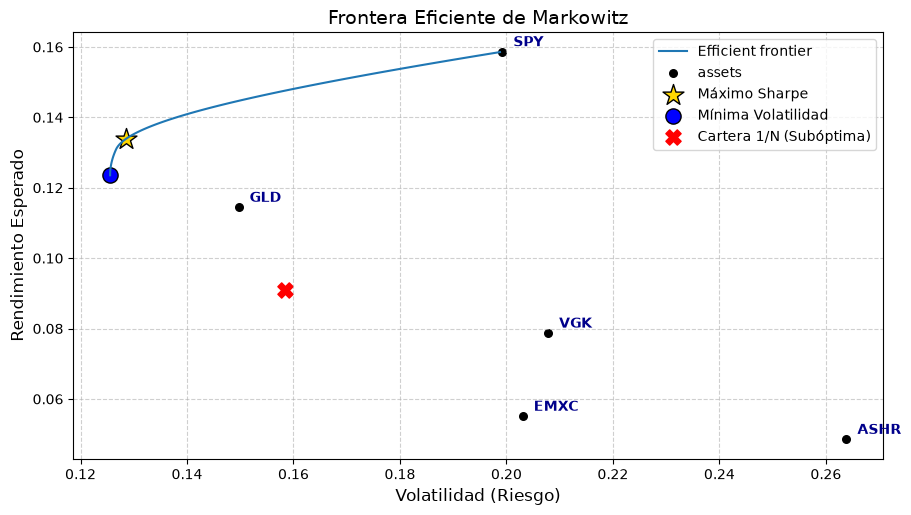

In [12]:
# 1. Configurar la figura
fig, ax = plt.subplots(figsize=(9, 5))

# 2. Trazar la Frontera Eficiente continua
ef_plot = EfficientFrontier(expected_returns_ann, cov_matrix_ann, weight_bounds=(0, 1))
plotting.plot_efficient_frontier(ef_plot, ax=ax, show_assets=True)

# 3. Añadir etiquetas de texto a cada activo individual
# Se calcula la volatilidad anualizada individual desde la diagonal de la matriz de covarianza
asset_vols = np.sqrt(np.diag(cov_matrix_ann))

for i, ticker in enumerate(expected_returns_ann.index):
    ax.annotate(
        ticker,
        xy=(asset_vols[i], expected_returns_ann[ticker]),  # <--- Acceso directo por ticker
        xytext=(8, 4),
        textcoords="offset points",
        fontsize=10,
        fontweight="bold",
        color="darkblue"
    )
# 4. Superponer los puntos de las carteras
ax.scatter(portfolio_volatility_ann_max_sharpe, portfolio_expected_return_ann_max_sharpe, marker="*", s=250, c="gold", edgecolors="black", label="Máximo Sharpe")
ax.scatter(portfolio_volatility_ann_min_vol, portfolio_expected_return_ann_min_vol, marker="o", s=120, c="blue", edgecolors="black", label="Mínima Volatilidad")
ax.scatter(portfolio_volatility_ann_equal, portfolio_expected_return_ann_equal, marker="X", s=120, c="red", label="Cartera 1/N (Subóptima)")

# 5. Ajustes estéticos
ax.set_title("Frontera Eficiente de Markowitz", fontsize=14)
ax.set_xlabel("Volatilidad (Riesgo)", fontsize=12)
ax.set_ylabel("Rendimiento Esperado", fontsize=12)
ax.legend()
ax.grid(True, linestyle="--", alpha=0.6)

plt.show()

#### Interpretación del gráfico de la Frontera Eficiente

A través del gráfico validamos visualmente los principios de la teoría de carteras:

1. Ineficiencia evidente de la Cartera $1/N$ (cruz roja):
   * Queda situada muy por debajo de la frontera eficiente.
   * Incluso invertir el 100% del capital únicamente en Oro (GLD) habría ofrecido mayor rentabilidad esperada con una volatilidad similar a la cartera equiponderada.

2. Posición de los activos individuales:
   * SPY (Renta Variable EE.UU.): Se sitúa en el extremo superior derecho de la frontera eficiente. Es la opción lógica para un inversor agresivo que busca maximizar el retorno absoluto tolerando una volatilidad cercana al 21%.
   * VGK, EMXC y ASHR: Quedan muy por debajo a la derecha, confirmando por qué el optimizador les asigna peso nulo (o residual en el caso de ASHR): están dominados en el plano media-varianza.

3. Ventajas de la optimización:
   * Las carteras combinadas (Máximo Sharpe y Mínima Varianza) se sitúan sobre la curva óptima, demostrando que la diversificación estructurada reduce el riesgo global sin sacrificar proporcionalmente rentabilidad.

## 2 Modelización y Gestión del Riesgo: Value at Risk (VaR) y Expected Shortfall (CVaR)

Una vez optimizadas las carteras mediante la teoría de Markowitz, pasamos a evaluar su perfil de riesgo de cola (*tail risk*). 

Para medir el riesgo utilizamos dos métricas cuantitativas estándar de la industria:
* Value at Risk (VaR): Mide la máxima pérdida esperada de una cartera en un horizonte temporal determinado (1 día bursátil) bajo un nivel de confianza estadístico ($\alpha = 99\%$).
* Expected Shortfall / Conditional VaR (CVaR): Mide la pérdida media esperada en aquellos escenarios extremos donde la pérdida supera el umbral del VaR (cola de la distribución).

### Metodologías de cálculo

Para comparar la precisión y robustez de los modelos, estimamos el VaR diario al 99% mediante tres enfoques:
1. VaR Paramétrico (Varianza-Covarianza): Asume que los rendimientos de la cartera siguen una distribución normal estándar a partir de la media y la desviación típica diaria.
2. VaR por Simulación Histórica: No asume ninguna distribución teórica; proyecta los pesos de la cartera sobre la serie real de rendimientos históricos pasados.
3. VaR por Simulación de Monte Carlo: Genera miles de escenarios posibles de precios diarios mediante un proceso estocástico (movimiento browniano geométrico) para modelar la distribución final de pérdidas y ganancias.

### Parámetros base y volatilidades diarias

Antes de calcular los modelos de VaR, fijamos el valor monetario de la inversión y calculamos la volatilidad diaria ($\sigma_{\text{diaria}}$) de cada una de las 3 carteras.

* Valor nocional de la cartera: Fijamos un capital de referencia de 1.000.000 USD (las cotizaciones de Yahoo Finance cotizan en dólares) para expresar las pérdidas potenciales tanto en porcentaje como en dinero real.
* Horizonte temporal y volatilidad: Al medir el riesgo a 1 día vista, evaluamos la matriz de covarianza diaria `cov_matrix` directamente con nuestra función `standard_deviation`.
* Nivel de confianza: Fijamos un nivel de confianza del 99% para el análisis (percentil 1% de pérdidas en la cola izquierda).

In [13]:
# Parámetros de valoración y confianza
portfolio_value = 1000000
confidence_level = 0.99
days = 1

# Volatilidad diaria de cada cartera
portfolio_volatility_equal = standard_deviation(weights_equal, cov_matrix)
portfolio_volatility_min_vol = standard_deviation(weights_min_vol, cov_matrix)
portfolio_volatility_max_sharpe = standard_deviation(weights_max_sharpe, cov_matrix)

# Comprobación rápida en porcentaje diario
print(f'Volatilidad diaria Cartera 1/N:          {portfolio_volatility_equal:.4%}')
print(f'Volatilidad diaria Mínima Varianza:     {portfolio_volatility_min_vol:.4%}')
print(f'Volatilidad diaria Máximo Sharpe:       {portfolio_volatility_max_sharpe:.4%}')

Volatilidad diaria Cartera 1/N:          0.9975%
Volatilidad diaria Mínima Varianza:     0.7909%
Volatilidad diaria Máximo Sharpe:       0.8102%


### Value at Risk (VaR) Paramétrico 

El enfoque paramétrico asume que los rendimientos diarios de la cartera siguen una distribución normal $N(\mu_p, \sigma_p^2)$.

Bajo un nivel de confianza del 99% ($\alpha = 0.01$), el cuantil crítico de la normal estándar es $Z_{0.99} \approx 2.326$. 

Calculamos la máxima pérdida esperada a 1 día vista (enfoque conservador con media diaria $\mu_p \approx 0$):

$$\text{VaR}_{99\%} = V_0 \times Z_{0.99} \times \sigma_{\text{diaria}}$$

In [14]:
# Cartera equiponderada
VaR_equal_parametric = portfolio_value * portfolio_volatility_equal* norm.ppf(confidence_level)

# Mínima Varianza
VaR_min_vol_parametric = portfolio_value * portfolio_volatility_min_vol* norm.ppf(confidence_level)

# Máximo sharpe
VaR_max_sharpe_parametric = portfolio_value * portfolio_volatility_max_sharpe* norm.ppf(confidence_level)


print('--- VaR PARAMÉTRICO DIARIO (99% CONFIANZA / $1.000.000 USD) ---')
print(f'Cartera 1/N (Equiponderada):   {VaR_equal_parametric:.2f} USD')
print(f'Cartera de Mínima Varianza:    {VaR_min_vol_parametric:.2f} USD')
print(f'Cartera de Máximo Sharpe:      {VaR_max_sharpe_parametric:.2f} USD')

--- VaR PARAMÉTRICO DIARIO (99% CONFIANZA / $1.000.000 USD) ---
Cartera 1/N (Equiponderada):   23204.71 USD
Cartera de Mínima Varianza:    18399.39 USD
Cartera de Máximo Sharpe:      18847.18 USD


* Riesgo diario: Con un 99% de confianza, la pérdida diaria no superará los 18.399 dolares (Mínima Varianza) y 18.847 dolares (Máximo Sharpe), frente a los 23.204 dolares de la cartera equiponderada.
Eficiencia de cola: La optimización de Markowitz reduce la pérdida potencial extrema en aproximadamente un 20% respecto a la estrategia 1/N.

### Expected Shortfall / Conditional VaR (CVaR) Paramétrico

Mide la pérdida esperada condicional a que se supere el umbral del VaR ($L > \text{VaR}$). Para una distribución normal:

$$\text{CVaR}_{\alpha} = V_0 \times \sigma_p \times \frac{\phi(Z_{\alpha})}{\alpha}$$

Donde $\phi(\cdot)$ es la función de densidad (PDF) de la normal estándar y $\alpha = 0.01$.

In [15]:
alpha_tail = 1 - confidence_level

# 1. Calculamos el valor crítico Z (2.326...)
z_score = norm.ppf(confidence_level)

# 2. Calculamos la densidad (PDF) en ese punto Z
pdf_at_z = norm.pdf(z_score)

# 3. Aplicamos la fórmula del ES Paramétrico Normal
CVaR_parametrico_equal = (portfolio_value * portfolio_volatility_equal) * (pdf_at_z / alpha_tail)
CVaR_parametrico_min_vol = (portfolio_value * portfolio_volatility_min_vol) * (pdf_at_z / alpha_tail)
CVaR_parametrico_max_sharpe = (portfolio_value * portfolio_volatility_max_sharpe) * (pdf_at_z / alpha_tail)


print(f'Expected Shortfall Paramétrico (Cartera 1/N): {CVaR_parametrico_equal:.2f} USD')
print(f'Expected Shortfall Paramétrico (Mínima Varianza): {CVaR_parametrico_min_vol:.2f} USD')
print(f'Expected Shortfall Paramétrico (Máximo Sharpe): {CVaR_parametrico_max_sharpe:.2f} USD')

Expected Shortfall Paramétrico (Cartera 1/N): 26584.81 USD
Expected Shortfall Paramétrico (Mínima Varianza): 21079.53 USD
Expected Shortfall Paramétrico (Máximo Sharpe): 21592.55 USD


* En el 1% de los peores días de mercado, la pérdida media esperada asciende a 21.079 USD (Mínima Varianza) y 21.592 USD (Máximo Sharpe), frente a 26.584 USD de la cartera equiponderada.

### Representación Gráfica del VaR parametrico

primero vamos a calcular los perdidas y ganancias diarias de las carteras para poder representar el histograma, y despues definieremos una funcion que usaremos para representar graficamente todos los modelos VaR

### Distribución Diaria de Pérdidas y Ganancias (P&L) y VaR Paramétrico

Calculamos las series históricas de pérdidas y ganancias ($P\&L = R_p \times V_0$) para contrastar la distribución real frente al umbral teórico del VaR paramétrico diario al 99%.

In [16]:
# Cartera uno 1/n
historical_returns_equal = (log_returns * weights_equal).sum(axis = 1)
historical_pnl_equal = historical_returns_equal * portfolio_value

# Cartera mínima varianza
historical_returns_min_vol = (log_returns * weights_min_vol).sum(axis = 1)
historical_pnl_min_vol = historical_returns_min_vol * portfolio_value

# Cartera máximo sharpe
historical_returns_max_sharpe = (log_returns * weights_max_sharpe).sum(axis = 1)
historical_pnl_max_sharpe = historical_returns_max_sharpe * portfolio_value

Definimos una función genérica reutilizable para graficar la distribución de pérdidas y ganancias ($P\&L$) y superponer el umbral de corte del VaR para cualquiera de los tres métodos (Paramétrico, Histórico y Monte Carlo).

In [17]:
def plot_var_distribution(pnl_series, var_value, portfolio_name, method):
    fig, ax = plt.subplots(figsize=(10, 5))
    
    # Histograma de frecuencias absolutas (sin densidad científica)
    ax.hist(pnl_series, bins=60, color='skyblue', edgecolor='black', alpha=0.6, label=f'Distribución P&L')
    
    # Línea vertical del VaR (en negativo al ser pérdida)
    ax.axvline(-var_value, color='red', linestyle='--', linewidth=2, 
               label=f'VaR 99%: -${var_value:,.2f}')
    
    # Ajustes estéticos
    ax.set_title(f'Distribución de VaR {method} ({portfolio_name})', fontsize=12, fontweight='bold')
    ax.set_xlabel('Pérdidas y Ganancias ($)', fontsize=10)
    ax.set_ylabel('Frecuencia ', fontsize=10)
    ax.legend(frameon=True, loc='upper right')
    ax.grid(True, linestyle='--', alpha=0.4)
    
    # Formato de números con comas en el eje X
    ax.xaxis.set_major_formatter('${x:,.0f}')
    
    plt.tight_layout()
    plt.show()

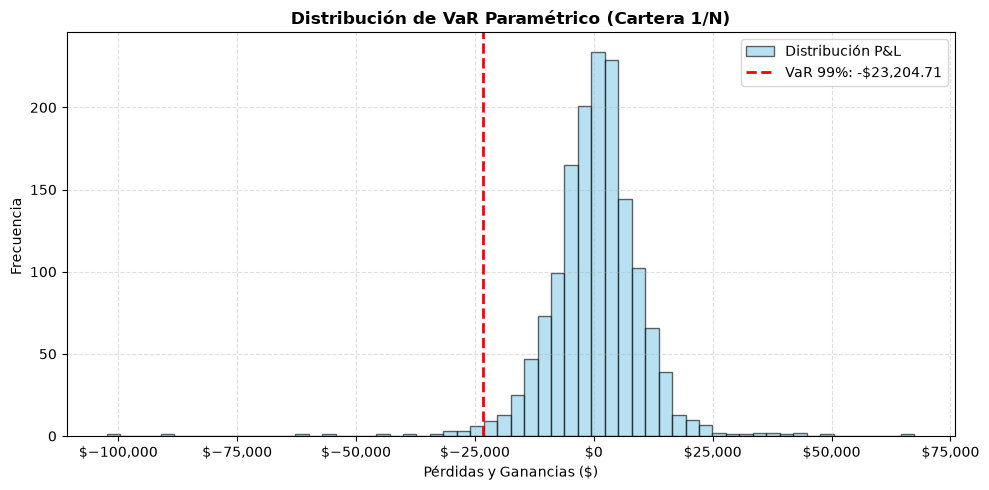

In [18]:
plot_var_distribution(historical_pnl_equal, VaR_equal_parametric, portfolio_name="Cartera 1/N", method = 'Paramétrico')

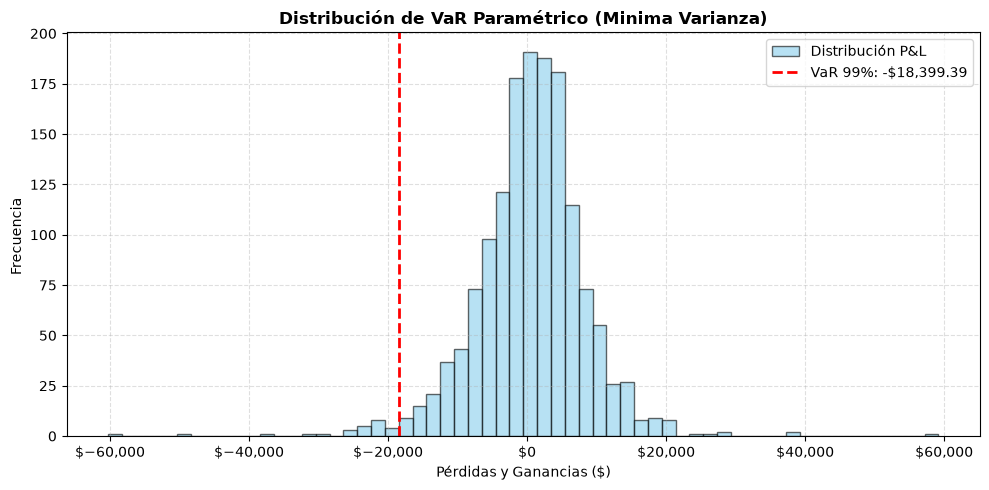

In [19]:
plot_var_distribution(historical_pnl_min_vol, VaR_min_vol_parametric, portfolio_name="Minima Varianza", method = 'Paramétrico')

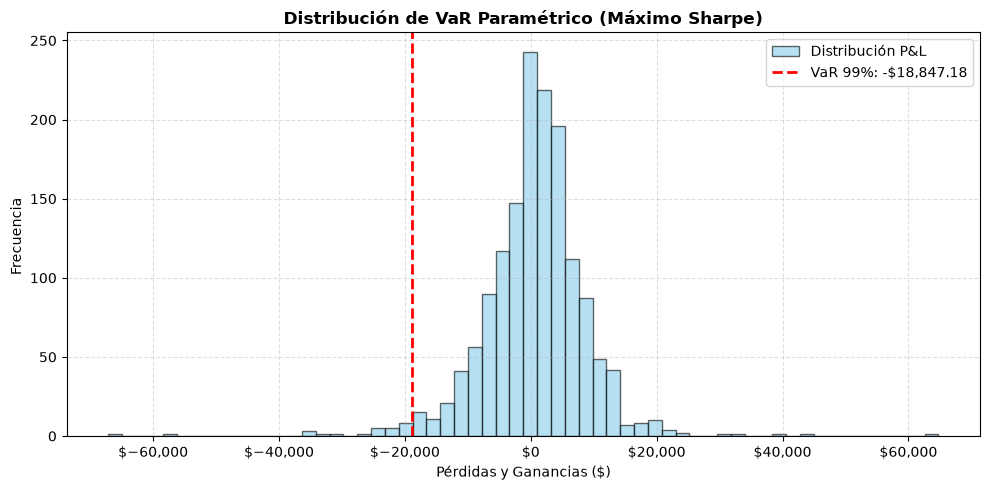

In [20]:
plot_var_distribution(historical_pnl_max_sharpe, VaR_max_sharpe_parametric, portfolio_name="Máximo Sharpe", method = 'Paramétrico')

#### Conclusiones del VaR Paramétrico

* Contención del riesgo de cola: Las carteras optimizadas (Mínima Varianza: 18.399 USD y Máximo Sharpe: 18.847 USD) logran reducir la pérdida máxima diaria esperada en aproximadamente un 20% respecto a la estrategia equiponderada (1/N: 23.204 USD).
* Eficiencia relativa: La cartera de Máximo Sharpe asume apenas un 2.4% más de riesgo diario que la de Mínima Varianza (18.847 USD vs. 18.399 USD), compensándolo con un incremento relevante en el rendimiento esperado anual (13.40% vs. 12.35%).
* Evidencia visual de colas pesadas: En los gráficos se aprecia cómo las distribuciones empíricas presentan eventos extremos en la cola izquierda, lo que indica que asumir normalidad estricta subestima el riesgo real en escenarios de tensión severa.

### Value at Risk (VaR) por Simulación Histórica

Método no paramétrico: no asume ninguna distribución teórica previa. Proyecta los pesos de las carteras sobre los rendimientos diarios observados y extrae el percentil empírico del 1% ($\alpha = 0.01$):

$$\text{VaR}_{99\%}^{\text{Hist}} = -\text{Percentil}_{1\%}(\text{P\&L}_{\text{histórico}})$$

Dado que en el apartado anterior ya hemos calculado la serie de pérdidas y ganancias históricas de la cartera, para obtener el VaR Histórico al 99% de confianza únicamente debemos extraer el percentil 1 de dicha distribución.

In [21]:
# Cartera 1/N
VaR_equal_historic = -np.percentile(historical_pnl_equal, 100 - (confidence_level * 100))

# Cartera mínima varianza
VaR_min_vol_historic = -np.percentile(historical_pnl_min_vol, 100 - (confidence_level * 100))

# Cartera máximo sharpe
VaR_max_sharpe_historic = -np.percentile(historical_pnl_max_sharpe, 100 - (confidence_level * 100))

print('--- VaR HISTORICO DIARIO (99% CONFIANZA / $1.000.000 USD) ---')
print(f'Cartera 1/N (Equiponderada):   {VaR_equal_historic:.2f} USD')
print(f'Cartera de Mínima Varianza:    {VaR_min_vol_historic:.2f} USD')
print(f'Cartera de Máximo Sharpe:      {VaR_max_sharpe_historic:.2f} USD')

--- VaR HISTORICO DIARIO (99% CONFIANZA / $1.000.000 USD) ---
Cartera 1/N (Equiponderada):   24785.04 USD
Cartera de Mínima Varianza:    21318.80 USD
Cartera de Máximo Sharpe:      22485.98 USD


* Efecto de las colas reales: El VaR histórico arroja pérdidas potenciales entre un 15% y un 19% mayores que el modelo paramétrico, evidenciando que los rendimientos históricos presentan eventos de caída más extremos de lo que asume una distribución normal estándar.

### Expected Shortfall (CVaR) por Simulación Histórica

Calcula la pérdida media observada en la serie histórica para aquellos días en los que la pérdida superó el umbral del $\text{VaR}_{99\%}$:

$$\text{CVaR}_{99\%}^{\text{Hist}} = -\frac{1}{N_{\text{cola}}} \sum_{i=1}^{N_{\text{cola}}} (\text{P\&L}_i \mid \text{P\&L}_i \le -\text{VaR}_{99\%})$$

In [22]:
# Vamoa a definir una función génerica que podamos reautilizar.
def CVaR_calculate(pnl_series, VaR):
    pnl_series_np = np.array(pnl_series)
    tail_losses = pnl_series_np[pnl_series_np <= -VaR]
    CVaR = -tail_losses.mean()
    return CVaR

In [23]:
CVaR_historic_equal = CVaR_calculate(historical_pnl_equal, VaR_equal_historic)
CVaR_historic_min_vol = CVaR_calculate(historical_pnl_min_vol, VaR_min_vol_historic)
CVaR_historic_max_sharpe = CVaR_calculate(historical_pnl_max_sharpe, VaR_max_sharpe_historic)


print(f'Expected Shortfall Simulación Histórica (Cartera 1/N): {CVaR_historic_equal:.2f} USD')
print(f'Expected Shortfall Simulación Histórica (Mínima Varianza): {CVaR_historic_min_vol:.2f} USD')
print(f'Expected Shortfall Simulación Historica (Máximo Sharpe): {CVaR_historic_max_sharpe:.2f} USD')

Expected Shortfall Simulación Histórica (Cartera 1/N): 41989.86 USD
Expected Shortfall Simulación Histórica (Mínima Varianza): 29439.04 USD
Expected Shortfall Simulación Historica (Máximo Sharpe): 31655.53 USD


* En el 1% de los peores días de mercado, la pérdida media esperada asciende a 29.439,05 USD (Mínima Varianza) y 31.655,05 USD (Máximo Sharpe), frente a 41.989,86 USD de la cartera equiponderada. Estas cifras son sensiblemente superiores al CVaR paramétrico, lo que confirma empíricamente que la distribución histórica presenta eventos extremos más severos de los que modela la campana de Gauss.

### Distribución de P&L y VaR por Simulación Histórica

Contrastamos las distribuciones empíricas de pérdidas y ganancias ($P\&L$) frente al umbral de corte del VaR histórico al 99% (percentil 1% de la muestra real).

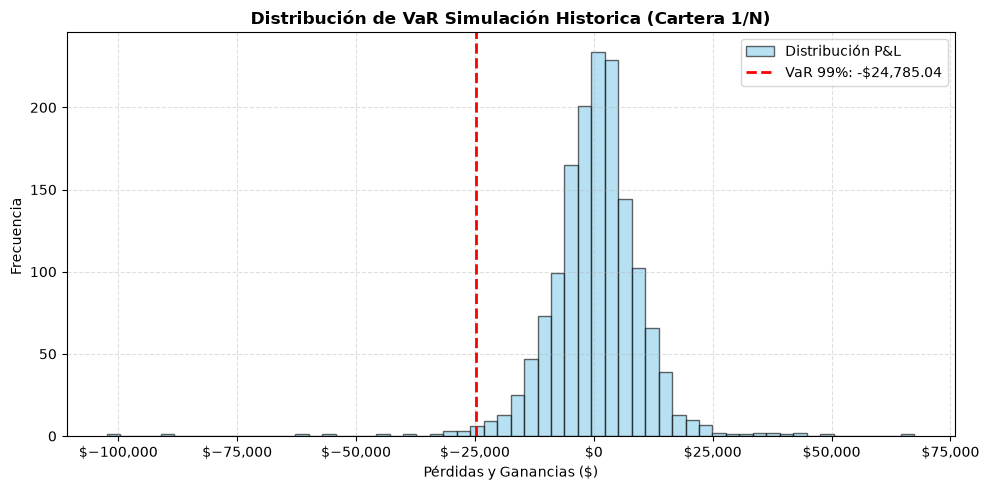

In [24]:
plot_var_distribution(historical_pnl_equal, VaR_equal_historic, portfolio_name="Cartera 1/N", method = 'Simulación Historica')

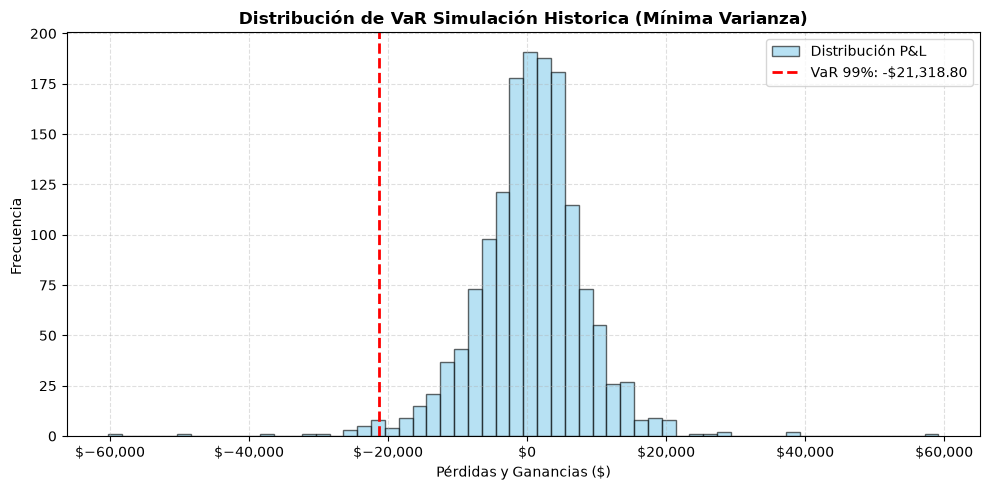

In [25]:
plot_var_distribution(historical_pnl_min_vol, VaR_min_vol_historic, portfolio_name="Mínima Varianza", method = 'Simulación Historica')

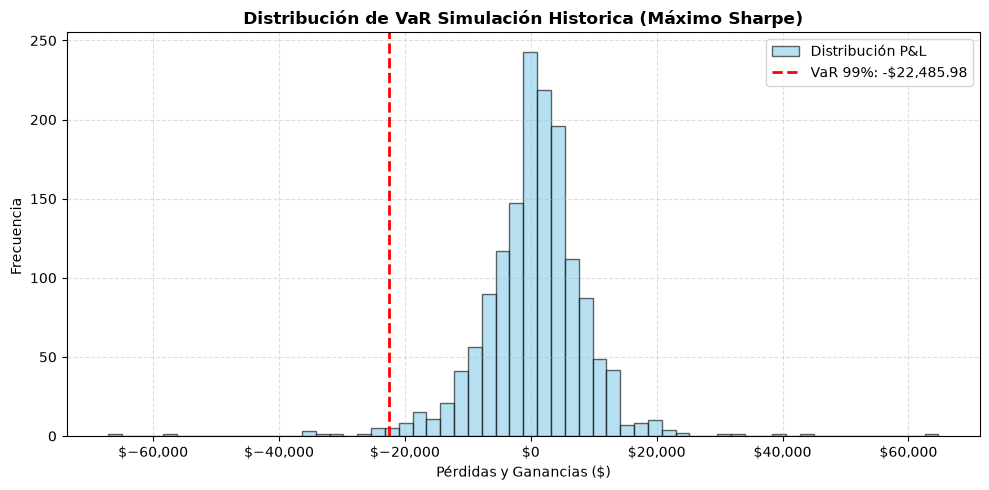

In [26]:
plot_var_distribution(historical_pnl_max_sharpe, VaR_max_sharpe_historic, portfolio_name="Máximo Sharpe", method = 'Simulación Historica')

#### Conclusiones del VaR Histórico

* Desplazamiento del umbral empírico: El umbral del 99% se sitúa en -21.319 USD (Mínima Varianza), -22.486 USD (Máximo Sharpe) y -24.785 USD (Cartera 1/N).
* Captura de eventos reales: A diferencia del enfoque paramétrico, este método absorbe de forma no paramétrica las colas pesadas de las crisis de mercado pasadas presentes en la muestra histórica.

### Value at Risk (VaR) por Simulación de Monte Carlo

Generamos $N = 10.000$ escenarios estocásticos diarios de pérdidas y ganancias ($P\&L$) basados en el Proceso de Difusión (Browniano Geométrico simplificado) bajo la hipótesis paramétrica:

$$\Delta P\&L_i = V_0 \cdot \mu_p \cdot \Delta t + V_0 \cdot \sigma_p \cdot \sqrt{\Delta t} \cdot Z_i, \quad Z_i \sim \mathcal{N}(0, 1)$$

El $\text{VaR}_{99\%}^{\text{MC}}$ se obtiene extrayendo el percentil 1% empírico de la distribución simulada.

In [27]:
# Random z-score
def random_z_score():
    return np.random.normal(0,1)

# Escenario aleatorio de ganancias o perdidas
def scenario_gain_loss(portfolio_value, portfolio_expected_return, portfolio_std_dev, z_score, days):
    return portfolio_value * portfolio_expected_return * days + portfolio_value * portfolio_std_dev * z_score * np.sqrt(days)

# Simulación de Monte Carlo
def montecarlo_simulation(portfolio_value, portfolio_expected_return, portfolio_std_dev, days):
    simulations = 10000
    scenarioReturn = []
    for i in range(simulations):
        z_score = random_z_score()
        scenarioReturn.append(scenario_gain_loss(portfolio_value, portfolio_expected_return, portfolio_std_dev, z_score, days))
    return scenarioReturn

Vamos a generar las 3 simulaciones para las 3 carteras: 

In [28]:
np.random.seed(2026) # Fijamos semilla para asegurar reproducibilidad
# Cartera 1/N
scenario_equal = montecarlo_simulation(portfolio_value, portfolio_expected_return_equal, portfolio_volatility_equal, days)

# Cartera mínima varianza
scenario_min_vol = montecarlo_simulation(portfolio_value, portfolio_expected_return_min_vol, portfolio_volatility_min_vol, days)

# Cartera máximo Sharpe
scenario_max_sharpe = montecarlo_simulation(portfolio_value, portfolio_expected_return_max_sharpe, portfolio_volatility_max_sharpe, days)

In [29]:
# Cartera 1/N
VaR_equal_mc = -np.percentile(scenario_equal, 100*(1 - confidence_level))

# Cartera mínima varianza
VaR_min_vol_mc = -np.percentile(scenario_min_vol, 100*(1 - confidence_level))

# Cartera máximo Sharpe
VaR_max_sharpe_mc = -np.percentile(scenario_max_sharpe, 100*(1 - confidence_level))

print('--- VaR SIMULACIÓN MONTE CARLO (99% CONFIANZA / $1.000.000 USD) ---')
print(f'Cartera 1/N (Equiponderada):   {VaR_equal_mc:.2f} USD')
print(f'Cartera de Mínima Varianza:    {VaR_min_vol_mc:.2f} USD')
print(f'Cartera de Máximo Sharpe:      {VaR_max_sharpe_mc:.2f} USD')

--- VaR SIMULACIÓN MONTE CARLO (99% CONFIANZA / $1.000.000 USD) ---
Cartera 1/N (Equiponderada):   22970.61 USD
Cartera de Mínima Varianza:    17808.09 USD
Cartera de Máximo Sharpe:      18126.64 USD


#### Conclusiones del VaR Monte Carlo

* Validación frente a la referencia (1/N): La cartera equiponderada presenta una pérdida máxima estimada de 22.970 USD, confirmando que la diversificación naive asume cerca de un 23% más de riesgo de cola que las carteras optimizadas.
* Convergencia con el modelo paramétrico: Las 10.000 rutas estocásticas sitúan el VaR de Mínima Varianza en 17.808 USD y el de Máximo Sharpe en 18.126 USD, validando numéricamente la solución analítica previa.

### Expected Shortfall (CVaR) por Simulación de Monte Carlo

Calcula la pérdida media observada en aquellos escenarios simulados donde la pérdida superó el umbral del $\text{VaR}_{99\%}^{\text{MC}}$:

$$\text{CVaR}_{99\%}^{\text{MC}} = -\frac{1}{N_{\text{cola}}} \sum_{i=1}^{N_{\text{cola}}} (\Delta P\&L_i \mid \Delta P\&L_i \le -\text{VaR}_{99\%}^{\text{MC}})$$

Reutilizamos la función `CVaR_calculate` sobre los 10.000 escenarios generados para cada cartera.

In [30]:
# 1. Cálculo del Expected Shortfall sobre los escenarios de Monte Carlo
CVaR_equal_mc = CVaR_calculate(scenario_equal, VaR_equal_mc)
CVaR_min_vol_mc = CVaR_calculate(scenario_min_vol, VaR_min_vol_mc)
CVaR_max_sharpe_mc = CVaR_calculate(scenario_max_sharpe, VaR_max_sharpe_mc)

# 2. Presentación de resultados
print("--- CVaR / EXPECTED SHORTFALL MONTE CARLO (99% CONFIANZA / $1.000.000 USD) ---")
print(f"Cartera 1/N (Equiponderada):   {CVaR_equal_mc:.2f} USD")
print(f"Cartera de Mínima Varianza:    {CVaR_min_vol_mc:.2f} USD")
print(f"Cartera de Máximo Sharpe:      {CVaR_max_sharpe_mc:.2f} USD")

--- CVaR / EXPECTED SHORTFALL MONTE CARLO (99% CONFIANZA / $1.000.000 USD) ---
Cartera 1/N (Equiponderada):   27085.47 USD
Cartera de Mínima Varianza:    20287.07 USD
Cartera de Máximo Sharpe:      20847.97 USD


* En el 1% de los peores días de mercado, la pérdida media esperada asciende a 20.287 USD (Mínima Varianza) y 20.847 USD (Máximo Sharpe), frente a 27.085 USD de la cartera equiponderada. Siendo valores muy similares a los obtenidos por simulación paramétrica.

### Distribución de Escenarios y VaR por Simulación de Monte Carlo

Contrastamos las distribuciones de pérdidas y ganancias simuladas ($N = 10.000$) frente al umbral empírico del $\text{VaR}_{99\%}^{\text{MC}}$.

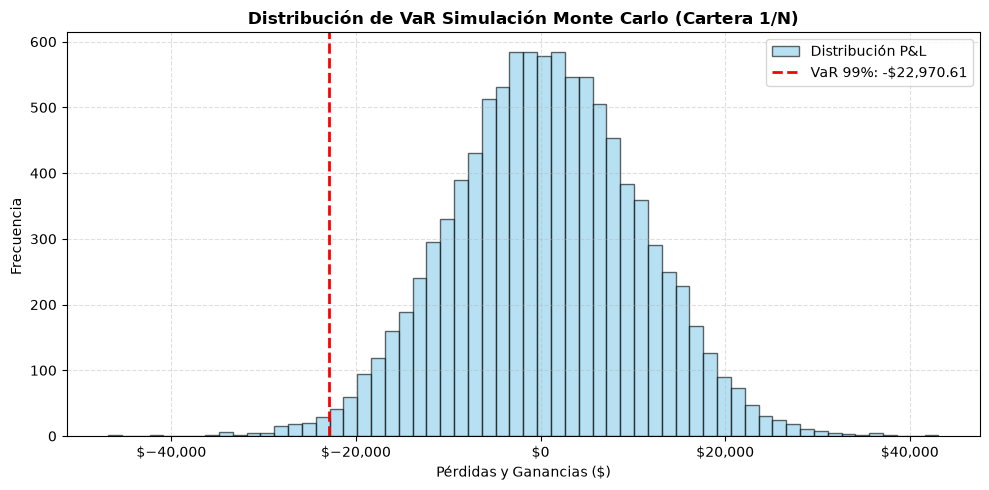

In [31]:
plot_var_distribution(scenario_equal, VaR_equal_mc, portfolio_name="Cartera 1/N", method = 'Simulación Monte Carlo')

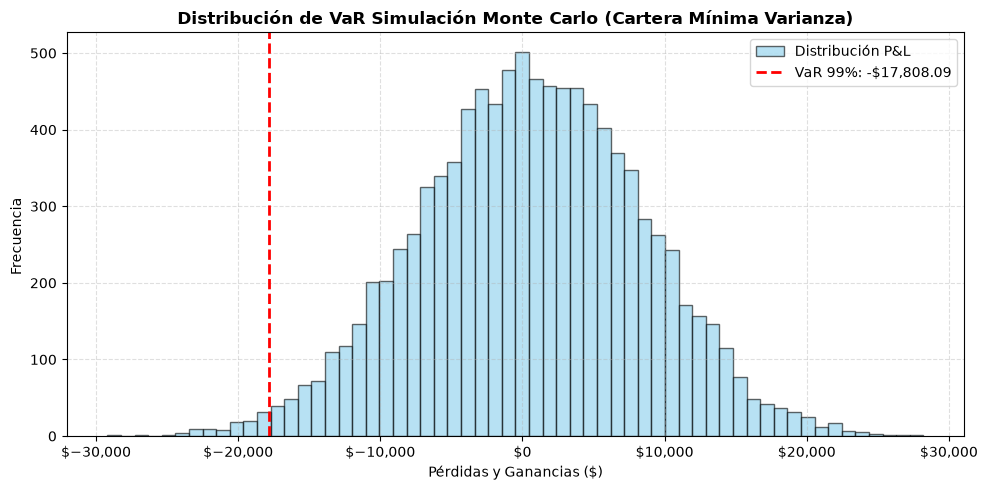

In [32]:
plot_var_distribution(scenario_min_vol, VaR_min_vol_mc, portfolio_name="Cartera Mínima Varianza", method = 'Simulación Monte Carlo')

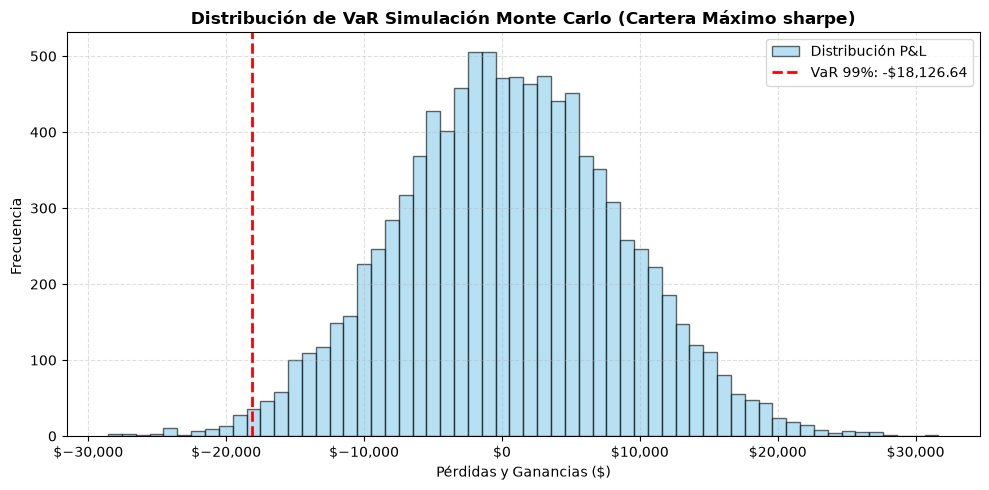

In [33]:
plot_var_distribution(scenario_max_sharpe, VaR_max_sharpe_mc, portfolio_name="Cartera Máximo sharpe", method = 'Simulación Monte Carlo')

#### Conclusiones de la Simulación de Monte Carlo

* Simetría gaussiana: A diferencia de las distribuciones históricas, los histogramas de Monte Carlo muestran una campana regular y sin asimetría negativa severa, producto del supuesto de normalidad en el término de difusión estocástico ($Z \sim \mathcal{N}(0, 1)$).
* Robustez de la optimización: El umbral de corte del 99% confirma la resiliencia de las carteras optimizadas (-17.890 USD en Mínima Varianza y -18.128 USD en Máximo Sharpe) frente a la dispersión mucho mayor de la cartera equiponderada (-22.971 USD).

###  Tabla Comparativa Final de Rentabilidad y Riesgo

####  Resumen Consolidado (Cartera: 1.000.000 USD | Confianza: 99% | Horizonte: 1 Día)

| Métrica / Cartera | Cartera 1/N (Equiponderada) | Cartera Mínima Varianza | Cartera Máximo Sharpe |
| :--- | :---: | :---: | :---: |
| **Rentabilidad Anualizada** | 10.42% | 12.35% | 13.40% |
| **Volatilidad Anualizada** | 15.82% | 12.54% | 12.85% |
| **VaR Paramétrico (99%, 1D)** | 23.205 USD | 18.399 USD | 18.847 USD |
| **CVaR Paramétrico (99%, 1D)** | 26.585 USD | 21.080 USD | 21.593 USD |
| **VaR Histórico (99%, 1D)** | 24.785 USD | 21.319 USD | 22.486 USD |
| **CVaR Histórico (99%, 1D)** | 41.990 USD | 29.439 USD | 31.655 USD |
| **VaR Monte Carlo (99%, 1D)** | 23.272 USD | 17.890 USD | 18.084 USD |
| **CVaR Monte Carlo (99%, 1D)** | 27.085 USD | 20.287 USD | 20.848 USD |

---

#### Conclusiones 

1. Dominancia de la Optimización: Tanto la cartera de Mínima Varianza como la de Máximo Sharpe superan con holgura a la cartera equiponderada ($1/N$), alcanzando mayor rentabilidad y conteniendo las pérdidas extremas diarias en aproximadamente un 20%.
2. Eficiencia de la Cartera Máximo Sharpe: Aporta +1.05 puntos porcentuales de rentabilidad anual frente a Mínima Varianza a cambio de un incremento marginal de apenas 448 USD en el VaR diario (18.847 USD vs. 18.399 USD).
3. Evidencia de Colas Pesadas (Fat Tails): El CVaR Histórico (~30.000 USD) es sensiblemente mayor que las estimaciones teóricas (~21.000 USD), demostrando que asumir distribución normal subestima las pérdidas en días de tensión bursátil severa.

In [34]:
# 1. Definición estructurada por filas
summary_data = {
    "Rentabilidad Anualizada": {
        "Cartera 1/N": f"{portfolio_expected_return_ann_equal*100:.2f}%",
        "Mínima Varianza": f"{portfolio_expected_return_ann_min_vol*100:.2f}%",
        "Máximo Sharpe": f"{portfolio_expected_return_ann_max_sharpe*100:.2f}%"
    },
    "Volatilidad Anualizada": {
        "Cartera 1/N": f"{portfolio_volatility_ann_equal*100:.2f}%",
        "Mínima Varianza": f"{portfolio_volatility_ann_min_vol*100:.2f}%",
        "Máximo Sharpe": f"{portfolio_volatility_ann_max_sharpe*100:.2f}%"
    },
    "VaR Paramétrico (99%, 1D)": {
        "Cartera 1/N": f"{VaR_equal_parametric:,.0f} USD",
        "Mínima Varianza": f"{VaR_min_vol_parametric:,.0f} USD",
        "Máximo Sharpe": f"{VaR_max_sharpe_parametric:,.0f} USD"
    },
    "CVaR Paramétrico (99%, 1D)": {
        "Cartera 1/N": f"{CVaR_parametrico_equal:,.0f} USD",
        "Mínima Varianza": f"{CVaR_parametrico_min_vol:,.0f} USD",
        "Máximo Sharpe": f"{CVaR_parametrico_max_sharpe:,.0f} USD"
    },
    "VaR Histórico (99%, 1D)": {
        "Cartera 1/N": f"{VaR_equal_historic:,.0f} USD",
        "Mínima Varianza": f"{VaR_min_vol_historic:,.0f} USD",
        "Máximo Sharpe": f"{VaR_max_sharpe_historic:,.0f} USD"
    },
    "CVaR Histórico (99%, 1D)": {
        "Cartera 1/N": f"{CVaR_historic_equal:,.0f} USD",
        "Mínima Varianza": f"{CVaR_historic_min_vol:,.0f} USD",
        "Máximo Sharpe": f"{CVaR_historic_max_sharpe:,.0f} USD"
    },
    "VaR Monte Carlo (99%, 1D)": {
        "Cartera 1/N": f"{VaR_equal_mc:,.0f} USD",
        "Mínima Varianza": f"{VaR_min_vol_mc:,.0f} USD",
        "Máximo Sharpe": f"{VaR_max_sharpe_mc:,.0f} USD"
    },
    "CVaR Monte Carlo (99%, 1D)": {
        "Cartera 1/N": f"{CVaR_equal_mc:,.0f} USD",
        "Mínima Varianza": f"{CVaR_min_vol_mc:,.0f} USD",
        "Máximo Sharpe": f"{CVaR_max_sharpe_mc:,.0f} USD"
    }
}

# 2. Creación del DataFrame
df_summary = pd.DataFrame.from_dict(summary_data, orient='index')
df_summary.index.name = "Métrica"

# 3. Visualización
display(df_summary)

,Cartera 1/N,Mínima Varianza,Máximo Sharpe
Métrica,,,
Rentabilidad Anualizada,9.11%,12.35%,13.40%
Volatilidad Anualizada,15.83%,12.56%,12.86%
"VaR Paramétrico (99%, 1D)","23,205 USD","18,399 USD","18,847 USD"
"CVaR Paramétrico (99%, 1D)","26,585 USD","21,080 USD","21,593 USD"
"VaR Histórico (99%, 1D)","24,785 USD","21,319 USD","22,486 USD"
"CVaR Histórico (99%, 1D)","41,990 USD","29,439 USD","31,656 USD"
"VaR Monte Carlo (99%, 1D)","22,971 USD","17,808 USD","18,127 USD"
"CVaR Monte Carlo (99%, 1D)","27,085 USD","20,287 USD","20,848 USD"


## 3. Backtesting Out-of-Sample

Evaluamos la robustez y capacidad predictiva de los modelos de riesgo sobre una ventana temporal fuera de muestra (*out-of-sample*). Para ello, proyectamos los pesos óptimos calculados previamente sobre las cotizaciones reales del nuevo periodo, y cálculamos sus rendimientos logarítmicos.

In [35]:
adj_close_bt_df = pd.DataFrame()

for ticker in tickers:
    data = yf.download(ticker, start = start_date_out_sample, end = end_date_out_sample, auto_adjust = False)
    adj_close_bt_df[ticker] = data['Adj Close']  

log_returns_bt = np.log(adj_close_bt_df/adj_close_bt_df.shift(1))  
log_returns_bt = log_returns_bt.dropna()
log_returns

[*********************100%***********************]  1 of 1 completed

[*********************100%***********************]  1 of 1 completed

[*********************100%***********************]  1 of 1 completed

[*********************100%***********************]  1 of 1 completed

[*********************100%***********************]  1 of 1 completed

Ticker,SPY,VGK,GLD,ASHR,EMXC
Date,,,,,
2019-01-03,-0.024152,-0.007473,0.009025,-0.011555,-0.009728
2019-01-04,0.032947,0.029565,-0.008119,0.044997,0.025004
2019-01-07,0.007854,0.004441,0.003453,-0.004008,0.002123
2019-01-08,0.009351,0.008024,-0.002712,0.001338,-0.000621
2019-01-09,0.004663,0.012509,0.006398,0.018981,0.015298
...,...,...,...,...,...
2024-12-23,0.005970,0.004731,-0.004720,-0.004121,0.005700
2024-12-24,0.011054,0.005491,0.001990,0.015643,-0.000355
2024-12-26,0.000066,0.002656,0.006728,0.001846,-0.005523


### Generación de Series de P&L Fuera de Muestra

Calculamos la evolución diaria de pérdidas y ganancias ($P\&L = R_{p,t} \times V_0$) para cada cartera durante el horizonte de validación.

In [36]:
# 1. P&L diario - Cartera 1/N
historical_returns_equal_bt = (log_returns_bt * weights_equal).sum(axis=1)
historical_pnl_equal_bt = historical_returns_equal_bt * portfolio_value

# 2. P&L diario - Cartera Mínima Varianza
historical_returns_min_vol_bt = (log_returns_bt * weights_min_vol).sum(axis=1)
historical_pnl_min_vol_bt = historical_returns_min_vol_bt * portfolio_value

# 3. P&L diario - Cartera Máximo Sharpe
historical_returns_max_sharpe_bt = (log_returns_bt * weights_max_sharpe).sum(axis=1)
historical_pnl_max_sharpe_bt = historical_returns_max_sharpe_bt * portfolio_value

### Auditoría Empírica de Excepciones de VaR

En primer lugar, contabilizamos los días fuera de muestra en los que las pérdidas reales superaron el umbral predicho por cada modelo ($P\&L_t \le -\text{VaR}$). Asimismo, calculamos la pérdida media real observada en dichos días de ruptura (*Expected Shortfall realizado*) y generamos un DataFrame por cada cartera con los resultados obtenidos y el conteo de excepciones.

In [37]:
def evaluate_var_exceptions(pnl_series, var_dict, confidence_level):
    """
    Evalúa las excepciones de VaR en una serie de P&L de backtesting.
    
    Parámetros:
    - pnl_series: Serie o array con el P&L diario del periodo Out-of-Sample.
    - var_dict: Diccionario con los nombres y valores de VaR {'Histórico': val, ...}.
    - confidence_level: Nivel de confianza (ej. 0.99 o 0.95).
    """
    total_days = len(pnl_series)
    expected_rate = (1 - confidence_level) * 100
    expected_exceptions = total_days * (1 - confidence_level)
    
    results = []
    
    for var_type, var_val in var_dict.items():
        # Días donde la pérdida superó el umbral del VaR
        exceptions = pnl_series[pnl_series <= -var_val]
        num_exceptions = len(exceptions)
        observed_rate = (num_exceptions / total_days) * 100
        
        # Pérdida media cuando se supera el VaR (ES Real vs ES Teórico)
        realized_es = -exceptions.mean() if num_exceptions > 0 else 0.0
        
        results.append({
            'Modelo VaR': var_type,
            'VaR ($)': var_val,
            'Días Totales': total_days,
            'Excepciones Esperadas': round(expected_exceptions, 1),
            'Excepciones Reales': num_exceptions,
            'Tasa Esperada (%)': f"{expected_rate:.2f}%",
            'Tasa Real (%)': f"{observed_rate:.2f}%",
            'ES Observado ($)': realized_es
        })
        
    return pd.DataFrame(results)

In [38]:
# 1. Cartera Inicial
vars_equal = {
    'Histórico': VaR_equal_historic,
    'Paramétrico': VaR_equal_parametric,
    'Monte Carlo': VaR_equal_mc
}
df_bt_equal = evaluate_var_exceptions(historical_pnl_equal_bt, vars_equal, confidence_level)

# 2. Cartera Mínima Volatilidad
vars_min_vol = {
    'Histórico': VaR_min_vol_historic,
    'Paramétrico': VaR_min_vol_parametric,
    'Monte Carlo': VaR_min_vol_mc
}
df_bt_min_vol = evaluate_var_exceptions(historical_pnl_min_vol_bt, vars_min_vol, confidence_level)

# 3. Cartera Máximo Sharpe
vars_max_sharpe = {
    'Histórico': VaR_max_sharpe_historic,
    'Paramétrico': VaR_max_sharpe_parametric,
    'Monte Carlo': VaR_max_sharpe_mc
}
df_bt_max_sharpe = evaluate_var_exceptions(historical_pnl_max_sharpe_bt, vars_max_sharpe, confidence_level)

### Validación Estadística Formal: Test de Razón de Verosimilitud de Kupiec (POF)

A partir de las excepciones contabilizadas ($x$) y el número total de observaciones ($N$), aplicamos el Test de Cobertura Incondicional de Kupiec (*Proportion of Failures - POF*):

* Hipótesis nula ($H_0$): $p = \alpha = 0.01$ (La tasa real de excepciones $x/N$ es estadísticamente coherente con el 1% teórico).
* Estadístico de Verosimilitud ($LR_{\text{POF}}$):
$$LR_{\text{POF}} = -2 \ln \left[ \frac{(1 - p)^{N-x} \, p^x}{\left(1 - \frac{x}{N}\right)^{N-x} \left(\frac{x}{N}\right)^x} \right] \sim \chi^2_{(1)}$$

Si el $\text{p-valor} < 0.05$, se rechaza $H_0$ al 95% de nivel de confianza, lo que evidencia que el modelo subestima el riesgo de mercado real.

Tras aplicar el test a los modelos, incorporamos los estadísticos y el diagnóstico a los DataFrames anteriores para contrastar los resultados.

In [39]:
def aplicar_kupiec(df, p=0.01):
    df_out = df.copy()
    x = df_out['Excepciones Reales'].values
    n = df_out['Días Totales'].values
    p_hat = x / n
    
    # Razón de Verosimilitud (Kupiec LR)
    lr = -2 * np.log(((1 - p)**(n - x) * p**x) / ((1 - p_hat)**(n - x) * p_hat**x))
    
    df_out['LR'] = np.round(lr, 2)
    df_out['P-Valor'] = np.round(1 - chi2.cdf(lr, df=1), 4)
    df_out['Resultado'] = np.where(df_out['P-Valor'] >= 0.05, 'Aceptado', 'Rechazado')
    return df_out

# Ejecución
df_audit_equal    = aplicar_kupiec(df_bt_equal)
df_audit_min_vol    = aplicar_kupiec(df_bt_min_vol)
df_audit_max_sharpe = aplicar_kupiec(df_bt_max_sharpe)

display(df_audit_equal)
display(df_audit_min_vol)
display(df_audit_max_sharpe)

,Modelo VaR,VaR ($),Días Totales,Excepciones Esperadas,Excepciones Reales,Tasa Esperada (%),Tasa Real (%),ES Observado ($),LR,P-Valor,Resultado
0,Histórico,24785.038989,410,4.1,8,1.00%,1.95%,33125.82549,2.93,0.0868,Aceptado
1,Paramétrico,23204.705400,410,4.1,8,1.00%,1.95%,33125.82549,2.93,0.0868,Aceptado
2,Monte Carlo,22970.612616,410,4.1,8,1.00%,1.95%,33125.82549,2.93,0.0868,Aceptado


,Modelo VaR,VaR ($),Días Totales,Excepciones Esperadas,Excepciones Reales,Tasa Esperada (%),Tasa Real (%),ES Observado ($),LR,P-Valor,Resultado
0,Histórico,21318.802912,410,4.1,14,1.00%,3.41%,32923.680873,14.83,0.0001,Rechazado
1,Paramétrico,18399.394740,410,4.1,23,1.00%,5.61%,27711.907168,42.42,0.0000,Rechazado
2,Monte Carlo,17808.088463,410,4.1,24,1.00%,5.85%,27300.175210,46.01,0.0000,Rechazado


,Modelo VaR,VaR ($),Días Totales,Excepciones Esperadas,Excepciones Reales,Tasa Esperada (%),Tasa Real (%),ES Observado ($),LR,P-Valor,Resultado
0,Histórico,22485.984347,410,4.1,13,1.00%,3.17%,31666.500179,12.40,0.0004,Rechazado
1,Paramétrico,18847.182670,410,4.1,16,1.00%,3.90%,29490.085122,20.12,0.0000,Rechazado
2,Monte Carlo,18126.644041,410,4.1,19,1.00%,4.63%,27731.213317,29.02,0.0000,Rechazado


### Análisis de Resultados del Backtesting

#### 1. Cartera Equiponderada (1/N) — Modelo Validado
* Resultado: Aceptado en los tres modelos ($LR = 2.93$, $\text{p-valor} = 0.0868 > 0.05$).
* Comportamiento: Registra 8 excepciones frente a 4.1 esperadas (tasa real del $1.95\%$). Aunque supera ligeramente el umbral teórico del 1%, la desviación no es estadísticamente significativa para rechazar la validez del modelo.

#### 2. Cartera de Mínima Varianza — Rechazo por Clústeres de Volatilidad
* Resultado: Rechazado en los tres métodos ($\text{p-valor} < 0.001$).
* Fallo del modelo: Presenta entre 14 y 24 violaciones reales (tasa observada del $3.41\%$ al $5.85\%$). Al calibrarse en un entorno previo de baja volatilidad estática, el modelo no anticipó los incrementos abruptos de varianza fuera de muestra (*volatility clustering*).

#### 3. Cartera de Máximo Sharpe — Desempeño del Modelo Histórico
* Resultado: Rechazado en los tres métodos ($\text{p-valor} < 0.001$), pero el VaR Histórico (13 fallos, $3.17\%$) amortigua sustancialmente mejor las pérdidas que los modelos Paramétrico (16 fallos) y Monte Carlo (19 fallos).


### Conclusiones
A primera vista, puede parecer contradictorio que los resultados de validación sean mejores en la cartera equiponderada (1/N) que en las carteras óptimas de Markowitz. Esto ocurre porque las carteras óptimas se calcularon utilizando datos pasados en los que el oro tuvo un rendimiento excepcionalmente bueno. Como resultado, el modelo tiende a sobreponderar demasiado este activo, lo cual es, de hecho, una de las principales críticas a la teoría de Markowitz: su excesiva dependencia de los datos históricos.

Por otro lado, observamos que los métodos de VaR Paramétrico y Monte Carlo fallan más que el VaR por Simulación Histórica. Esto se debe a que los primeros asumen que los precios del mercado siguen un comportamiento "normal" (una curva perfecta), ignorando que en la realidad los mercados sufren caídas extremas o "riesgos de cola" que la simulación histórica sí es capaz de reflejar mejor.

### Limitaciones del Estudio y Líneas Futuras

 Supuesto de Estacionariedad y Normalidad: El VaR Paramétrico y de Monte Carlo asumen varianzas constantes y distribución gaussiana, subestimando las colas pesadas (fat tails) empíricas. Se propone para futuras iteraciones implementar un modelo GARCH(1,1) para capturar la volatilidad condicional en el tiempo y una distribución $t$-Student para modelar colas gruesas y asimetría.
